# ML Robustness for Demand Prediction

**Goal**: Show that some ML models are more robust than others, i.e. small input changes lead to small output changes. We use:
- **PyCaret** for standard ML models
- **PyTorch** for FFNN, RNN, LSTM
- **auto_LiRPA (CROWN)** for certified robustness bounds on the FFNN
- **W&B** for experiment logging
- **Gradio** for interactive demo

**Inputs**: time of order (0–365 days), sentiment (−1 to +1)  
**Output**: demand (units)

In [ ]:
# Install required packages (run this cell first on Google Colab)
# Note: torch, scikit-learn, numpy, pandas, matplotlib are pre-installed in Colab
!pip install -q pycaret plotly wandb gradio
!pip install -q auto_LiRPA

In [9]:
# Cell 1: Imports & Setup
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'  # needed for some MPS ops

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import wandb
import joblib
from pathlib import Path

# === Set to False to load pretrained models instead of retraining ===
# First run: set RETRAIN = True to train and save models
# Subsequent runs: set RETRAIN = False to load saved models
MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)
RETRAIN = True

# Reproducibility
np.random.seed(966)
torch.manual_seed(966)

# Device — prefer Apple Silicon MPS, then CUDA, then CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
print(f"RETRAIN: {RETRAIN} — {'training from scratch' if RETRAIN else 'loading saved models'}")

Using device: mps
RETRAIN: True — training from scratch


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


              time    sentiment       demand
count  2000.000000  2000.000000  2000.000000
mean    181.838682     0.003650   109.194203
std     104.254099     0.566099    10.829220
min       0.208460    -0.999648    79.250612
25%      94.102195    -0.472377   101.153926
50%     181.351623     0.013295   108.715693
75%     270.450636     0.480434   116.520688
max     365.177650     0.998586   140.100934


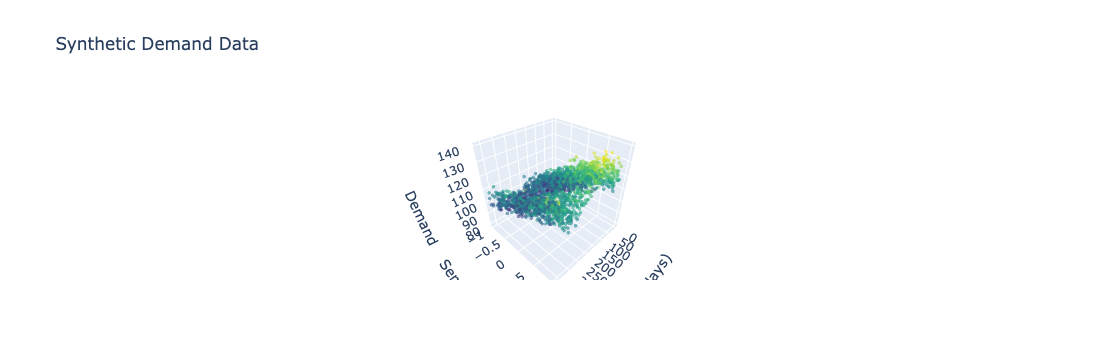

In [10]:
# Cell 2: W&B Init & Data Generation

wandb.init(project="demand-robustness-vnv", config={
    "n_samples": 2000, "epochs": 200, "lr": 1e-3, "batch_size": 64, "epsilon": 0.05
})

# --- Synthetic demand function ---
def demand_fn(t, s):
    """demand = trend + seasonality + sentiment effect + noise"""
    trend = 100 + 0.05 * t
    seasonal = 10 * np.sin(2 * np.pi * t / 365.25) + 5 * np.sin(2 * np.pi * t / 30.44)
    sentiment_effect = 15 * s * (1 + 0.3 * np.sin(2 * np.pi * t / 365.25))
    noise = np.random.normal(0, 3, size=t.shape)
    return trend + seasonal + sentiment_effect + noise

N = 2000
t_raw = np.random.uniform(0, 365.25, N)
s_raw = np.random.uniform(-1, 1, N)
d_raw = demand_fn(t_raw, s_raw)

df = pd.DataFrame({'time': t_raw, 'sentiment': s_raw, 'demand': d_raw})
print(df.describe())

# Quick 3D scatter
fig = go.Figure(data=[go.Scatter3d(
    x=df['time'], y=df['sentiment'], z=df['demand'],
    mode='markers', marker=dict(size=2, color=df['demand'], colorscale='Viridis', opacity=0.6)
)])
fig.update_layout(title='Synthetic Demand Data', scene=dict(
    xaxis_title='Time (days)', yaxis_title='Sentiment', zaxis_title='Demand'))
fig.show()

In [11]:
# Cell 3: Data Preparation & PyCaret Models

# --- Split & scale ---
X = df[['time', 'sentiment']].values
y = df['demand'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Save scalers (always, since data generation uses random seed)
joblib.dump(scaler_X, MODEL_DIR / "scaler_X.pkl")
joblib.dump(scaler_y, MODEL_DIR / "scaler_y.pkl")

# PyTorch tensors
X_train_t = torch.FloatTensor(X_train_s).to(device)
y_train_t = torch.FloatTensor(y_train_s).to(device)
X_test_t = torch.FloatTensor(X_test_s).to(device)
y_test_t = torch.FloatTensor(y_test_s).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)

# --- PyCaret ---
from pycaret.regression import setup, compare_models, pull, predict_model, save_model, load_model

df_train_pc = pd.DataFrame(X_train, columns=['time', 'sentiment'])
df_train_pc['demand'] = y_train
df_test_pc = pd.DataFrame(X_test, columns=['time', 'sentiment'])
df_test_pc['demand'] = y_test

pycaret_models = {}

if RETRAIN:
    reg = setup(data=df_train_pc, target='demand', session_id=42, verbose=False, fold=5)
    top3 = compare_models(n_select=3, sort='MAE')
    results = pull()
    print(results)
    wandb.log({"pycaret_results": wandb.Table(dataframe=results.reset_index())})

    for m in top3:
        name = type(m).__name__
        save_model(m, str(MODEL_DIR / f"pycaret_{name}"))
        preds = predict_model(m, data=df_test_pc)
        pycaret_models[name] = (m, preds['prediction_label'].values)
    # Save the list of model names for reloading
    joblib.dump(list(pycaret_models.keys()), MODEL_DIR / "pycaret_names.pkl")
    print(f"Saved {len(pycaret_models)} PyCaret models to {MODEL_DIR}/")
else:
    saved_names = joblib.load(MODEL_DIR / "pycaret_names.pkl")
    reg = setup(data=df_train_pc, target='demand', session_id=42, verbose=False, fold=5)
    for name in saved_names:
        m = load_model(str(MODEL_DIR / f"pycaret_{name}"))
        preds = predict_model(m, data=df_test_pc)
        pycaret_models[name] = (m, preds['prediction_label'].values)
    print(f"Loaded {len(pycaret_models)} PyCaret models from {MODEL_DIR}/")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,2.9569,13.7014,3.6939,0.8833,0.0340,0.0274,0.3620
gbr,Gradient Boosting Regressor,2.9858,14.2830,3.7649,0.8783,0.0347,0.0277,0.0120
rf,Random Forest Regressor,3.3880,18.1581,4.2514,0.8453,0.0393,0.0314,0.0220
et,Extra Trees Regressor,3.5221,19.6941,4.4246,0.8323,0.0409,0.0327,0.0200
ada,AdaBoost Regressor,3.9985,25.0372,4.9850,0.7867,0.0457,0.0370,0.0100
dt,Decision Tree Regressor,4.3540,30.3062,5.5009,0.7415,0.0505,0.0403,0.0040
ridge,Ridge Regression,5.4737,44.7263,6.6803,0.6193,0.0605,0.0503,0.1880
br,Bayesian Ridge,5.4741,44.7268,6.6803,0.6193,0.0605,0.0503,0.0060
lar,Least Angle Regression,5.4744,44.7268,6.6802,0.6193,0.0605,0.0503,0.1820
lr,Linear Regression,5.4744,44.7268,6.6802,0.6193,0.0605,0.0503,1.4720


                                    Model     MAE       MSE     RMSE      R2  \
lightgbm  Light Gradient Boosting Machine  2.9569   13.7014   3.6939  0.8833   
gbr           Gradient Boosting Regressor  2.9858   14.2830   3.7649  0.8783   
rf                Random Forest Regressor  3.3880   18.1581   4.2514  0.8453   
et                  Extra Trees Regressor  3.5221   19.6941   4.4246  0.8323   
ada                    AdaBoost Regressor  3.9985   25.0372   4.9850  0.7867   
dt                Decision Tree Regressor  4.3540   30.3062   5.5009  0.7415   
ridge                    Ridge Regression  5.4737   44.7263   6.6803  0.6193   
br                         Bayesian Ridge  5.4741   44.7268   6.6803  0.6193   
lar                Least Angle Regression  5.4744   44.7268   6.6802  0.6193   
lr                      Linear Regression  5.4744   44.7268   6.6802  0.6193   
huber                     Huber Regressor  5.4760   44.7510   6.6825  0.6190   
lasso                    Lasso Regressio

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2.9224,13.1097,3.6207,0.8829,0.0334,0.0272


Transformation Pipeline and Model Successfully Saved


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,3.1294,14.7306,3.8380,0.8685,0.0353,0.0291


Transformation Pipeline and Model Successfully Saved


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,3.2731,16.0924,4.0115,0.8563,0.0371,0.0305


Saved 3 PyCaret models to saved_models/


In [12]:
# Cell 4: Define & Train Neural Networks

class DemandFFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

class DemandRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(2, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.rnn(x.unsqueeze(1))
        return self.fc(out[:, -1, :])

class DemandLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x.unsqueeze(1))
        return self.fc(out[:, -1, :])

# --- Training function ---
def train_model(model, name, epochs=1000, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            pred = model(xb).squeeze()
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 100 == 0:
            model.eval()
            with torch.no_grad():
                test_pred = model(X_test_t).squeeze()
                test_loss = criterion(test_pred, y_test_t).item()
            wandb.log({f"{name}/train_loss": epoch_loss / len(train_loader),
                       f"{name}/test_loss": test_loss, "epoch": epoch + 1})
            print(f"{name} epoch {epoch+1}: train={epoch_loss/len(train_loader):.4f}, test={test_loss:.4f}")
    return model

NN_CLASSES = {"FFNN": DemandFFNN, "RNN": DemandRNN, "LSTM": DemandLSTM}

if RETRAIN:
    ffnn = train_model(DemandFFNN().to(device), "FFNN")
    rnn = train_model(DemandRNN().to(device), "RNN")
    lstm = train_model(DemandLSTM().to(device), "LSTM")
    nn_models = {"FFNN": ffnn, "RNN": rnn, "LSTM": lstm}

    # Save all models (CPU state dicts for portability)
    for name, model in nn_models.items():
        torch.save(model.cpu().state_dict(), MODEL_DIR / f"{name}.pt")
        model.to(device)
    print(f"Saved NN models to {MODEL_DIR}/")
else:
    nn_models = {}
    for name, cls in NN_CLASSES.items():
        model = cls()
        model.load_state_dict(torch.load(MODEL_DIR / f"{name}.pt", map_location="cpu", weights_only=True))
        model.to(device).eval()
        nn_models[name] = model
    ffnn, rnn, lstm = nn_models["FFNN"], nn_models["RNN"], nn_models["LSTM"]
    print(f"Loaded NN models from {MODEL_DIR}/")

FFNN epoch 100: train=0.2936, test=0.2899
FFNN epoch 200: train=0.2120, test=0.2236
FFNN epoch 300: train=0.1940, test=0.2129
FFNN epoch 400: train=0.1894, test=0.2130
FFNN epoch 500: train=0.1871, test=0.2100
FFNN epoch 600: train=0.1869, test=0.2088
FFNN epoch 700: train=0.1853, test=0.2062
FFNN epoch 800: train=0.1904, test=0.2091
FFNN epoch 900: train=0.1825, test=0.2076
FFNN epoch 1000: train=0.1820, test=0.2065
RNN epoch 100: train=0.3609, test=0.3419
RNN epoch 200: train=0.3574, test=0.3402
RNN epoch 300: train=0.3504, test=0.3371
RNN epoch 400: train=0.3435, test=0.3317
RNN epoch 500: train=0.3279, test=0.3214
RNN epoch 600: train=0.3000, test=0.2973
RNN epoch 700: train=0.2724, test=0.2686
RNN epoch 800: train=0.2396, test=0.2339
RNN epoch 900: train=0.2148, test=0.2128
RNN epoch 1000: train=0.2033, test=0.2057
LSTM epoch 100: train=0.3476, test=0.3336
LSTM epoch 200: train=0.3384, test=0.3324
LSTM epoch 300: train=0.2733, test=0.2783
LSTM epoch 400: train=0.2125, test=0.2150


                    Model   MAE     R²
                     FFNN 4.073 0.7817
                      RNN 4.071 0.7825
                     LSTM 3.992 0.7911
    RandomForestRegressor 3.273 0.8563
GradientBoostingRegressor 3.129 0.8685
            LGBMRegressor 2.922 0.8829


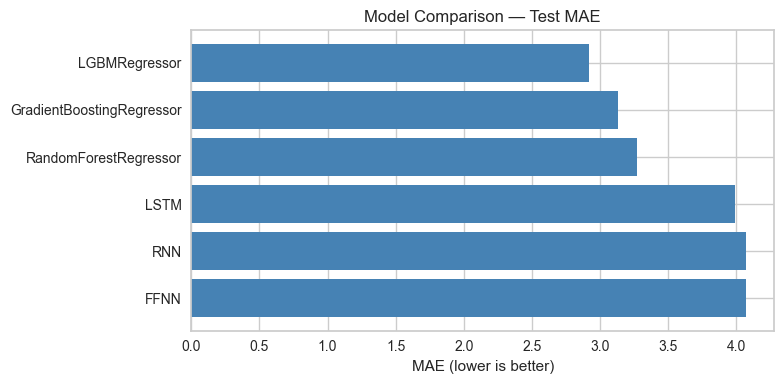

In [5]:
# Cell 5: Compare All Models

def nn_predict_original(model, X_scaled):
    """Predict in original demand scale."""
    model.eval()
    with torch.no_grad():
        pred_s = model(torch.FloatTensor(X_scaled).to(device)).cpu().numpy().ravel()
    return scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

rows = []
# PyCaret models
for name, (m, preds) in pycaret_models.items():
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    rows.append({"Model": name, "MAE": round(mae, 3), "R²": round(r2, 4)})

# Neural network models
for name, model in nn_models.items():
    preds = nn_predict_original(model, X_test_s)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    rows.append({"Model": name, "MAE": round(mae, 3), "R²": round(r2, 4)})

comparison_df = pd.DataFrame(rows).sort_values("MAE", ascending=False)
print(comparison_df.to_string(index=False))
wandb.log({"model_comparison": wandb.Table(dataframe=comparison_df)})

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(comparison_df['Model'], comparison_df['MAE'], color='steelblue')
ax.set_xlabel('MAE (lower is better)')
ax.set_title('Model Comparison — Test MAE')
plt.tight_layout()
plt.show()


Robustness (lower spread = more robust):
                    Model  Mean Spread  Max Spread      Type
            LGBMRegressor       12.396      16.970 Empirical
GradientBoostingRegressor        8.996      15.184 Empirical
    RandomForestRegressor       11.681      15.733 Empirical
                     FFNN        6.259       7.921 Empirical
                      RNN        5.484       9.953 Empirical
                     LSTM        5.936      10.157 Empirical
   FFNN (CROWN certified)        7.655       9.004    Formal

CROWN bounds contain all empirical samples: True


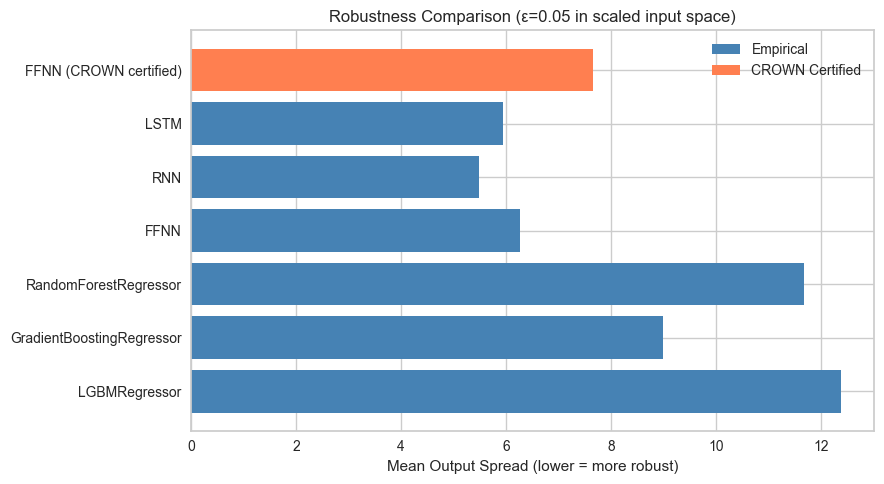

In [6]:
# Cell 6: Robustness Analysis — Empirical + Formal (CROWN)

from auto_LiRPA import BoundedModule, BoundedTensor, PerturbationLpNorm

EPS = 0.05  # perturbation radius in scaled [0,1] input space
N_PERTURB = 100
N_POINTS = 50

# Select test points
idx = np.random.choice(len(X_test_s), N_POINTS, replace=False)
test_pts = X_test_s[idx]

# --- Empirical robustness for ALL models ---
def empirical_spread(predict_fn, center_pts, eps, n_samples=100):
    """For each center point, sample perturbations and measure output spread."""
    spreads = []
    for pt in center_pts:
        perturbed = pt + np.random.uniform(-eps, eps, (n_samples, 2))
        perturbed = np.clip(perturbed, 0, 1)
        preds = predict_fn(perturbed)
        spreads.append(preds.max() - preds.min())
    return np.array(spreads)

# NN predict functions (in original scale) — auto-detect device from model
def make_nn_predictor(model):
    dev = next(model.parameters()).device
    def predict(X):
        model.eval()
        with torch.no_grad():
            p = model(torch.FloatTensor(X).to(dev)).cpu().numpy().ravel()
        return scaler_y.inverse_transform(p.reshape(-1, 1)).ravel()
    return predict

# PyCaret predict function
def make_pycaret_predictor(m):
    def predict(X):
        X_orig = scaler_X.inverse_transform(X)
        df_tmp = pd.DataFrame(X_orig, columns=['time', 'sentiment'])
        return np.asarray(m.predict(df_tmp)).ravel()
    return predict

robustness_rows = []

# PyCaret models
for name, (m, _) in pycaret_models.items():
    sp = empirical_spread(make_pycaret_predictor(m), test_pts, EPS, N_PERTURB)
    robustness_rows.append({"Model": name, "Mean Spread": round(sp.mean(), 3),
                            "Max Spread": round(sp.max(), 3), "Type": "Empirical"})

# NN models
for name, model in nn_models.items():
    sp = empirical_spread(make_nn_predictor(model), test_pts, EPS, N_PERTURB)
    robustness_rows.append({"Model": name, "Mean Spread": round(sp.mean(), 3),
                            "Max Spread": round(sp.max(), 3), "Type": "Empirical"})

# --- Formal bounds for FFNN using CROWN (auto_LiRPA) ---
# auto_LiRPA runs on CPU only
ffnn_cpu = DemandFFNN()
ffnn_cpu.load_state_dict({k: v.cpu() for k, v in ffnn.state_dict().items()})
ffnn_cpu.eval()

dummy = torch.zeros(1, 2)
bounded_ffnn = BoundedModule(ffnn_cpu, dummy)

crown_spreads = []
for pt in test_pts:
    center = torch.FloatTensor(pt).unsqueeze(0)
    ptb = PerturbationLpNorm(norm=float('inf'), eps=EPS)
    x_bounded = BoundedTensor(center, ptb)
    lb, ub = bounded_ffnn.compute_bounds(x=(x_bounded,), method='backward')
    lb_orig = scaler_y.inverse_transform(lb.detach().numpy().reshape(-1, 1)).ravel()[0]
    ub_orig = scaler_y.inverse_transform(ub.detach().numpy().reshape(-1, 1)).ravel()[0]
    crown_spreads.append(ub_orig - lb_orig)

crown_spreads = np.array(crown_spreads)
robustness_rows.append({"Model": "FFNN (CROWN certified)", "Mean Spread": round(crown_spreads.mean(), 3),
                         "Max Spread": round(crown_spreads.max(), 3), "Type": "Formal"})

rob_df = pd.DataFrame(robustness_rows)
print("\nRobustness (lower spread = more robust):")
print(rob_df.to_string(index=False))
wandb.log({"robustness": wandb.Table(dataframe=rob_df)})

# --- Verify that CROWN bounds contain empirical bounds ---
ffnn_empirical_sp = empirical_spread(make_nn_predictor(ffnn), test_pts, EPS, N_PERTURB)
valid = (crown_spreads >= ffnn_empirical_sp - 1e-3).all()
print(f"\nCROWN bounds contain all empirical samples: {valid}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if r['Type'] == 'Empirical' else 'coral' for _, r in rob_df.iterrows()]
ax.barh(rob_df['Model'], rob_df['Mean Spread'], color=colors)
ax.set_xlabel('Mean Output Spread (lower = more robust)')
ax.set_title(f'Robustness Comparison (ε={EPS} in scaled input space)')
ax.legend(handles=[plt.Rectangle((0,0),1,1,fc='steelblue'), plt.Rectangle((0,0),1,1,fc='coral')],
          labels=['Empirical', 'CROWN Certified'])
plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Gradio Interactive Demo — Combined

import gradio as gr
from auto_LiRPA import BoundedTensor, PerturbationLpNorm

# Build a dict of ALL available models (PyCaret + NN)
all_models = {}
for name, (m, _) in pycaret_models.items():
    all_models[name] = make_pycaret_predictor(m)
for name, model in nn_models.items():
    all_models[name] = make_nn_predictor(model)

MODEL_NAMES = list(all_models.keys())

# Precompute grid in scaled space
GRID_N = 40
t_grid = np.linspace(0, 1, GRID_N)
s_grid = np.linspace(0, 1, GRID_N)
T_mesh, S_mesh = np.meshgrid(t_grid, s_grid)
grid_pts = np.column_stack([T_mesh.ravel(), S_mesh.ravel()])

# Convert grid back to original scale for axis labels
grid_orig = scaler_X.inverse_transform(grid_pts)
T_orig = grid_orig[:, 0].reshape(GRID_N, GRID_N)
S_orig = grid_orig[:, 1].reshape(GRID_N, GRID_N)

# Precompute original-scale train/test data for scatter points
X_train_orig = scaler_X.inverse_transform(X_train_s)
X_test_orig = scaler_X.inverse_transform(X_test_s)

SURFACE_COLORS = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']

# ============================================================
# Tab 1: 3D Prediction Surfaces
# ============================================================
def plot_predictions(selected_models, show_crown, epsilon, show_train, show_test):
    fig = go.Figure()

    if show_train:
        fig.add_trace(go.Scatter3d(
            x=X_train_orig[:, 0], y=X_train_orig[:, 1], z=y_train,
            mode='markers', name='Train data',
            marker=dict(size=2, color='gray', opacity=0.3),
        ))
    if show_test:
        fig.add_trace(go.Scatter3d(
            x=X_test_orig[:, 0], y=X_test_orig[:, 1], z=y_test,
            mode='markers', name='Test data',
            marker=dict(size=3, color='black', opacity=0.5),
        ))

    for i, name in enumerate(selected_models):
        if name not in all_models:
            continue
        Z = all_models[name](grid_pts).reshape(GRID_N, GRID_N)
        c = SURFACE_COLORS[i % len(SURFACE_COLORS)]
        fig.add_trace(go.Surface(
            x=T_orig, y=S_orig, z=Z,
            name=name, showscale=False, opacity=0.7,
            colorscale=[[0, c], [1, c]], showlegend=True,
        ))

    if show_crown:
        lb_grid = np.zeros(len(grid_pts))
        ub_grid = np.zeros(len(grid_pts))
        for j, pt in enumerate(grid_pts):
            center = torch.FloatTensor(pt).unsqueeze(0)
            ptb = PerturbationLpNorm(norm=float('inf'), eps=epsilon)
            x_bounded = BoundedTensor(center, ptb)
            lb, ub = bounded_ffnn.compute_bounds(x=(x_bounded,), method='backward')
            lb_grid[j] = scaler_y.inverse_transform(lb.detach().numpy().reshape(-1, 1)).ravel()[0]
            ub_grid[j] = scaler_y.inverse_transform(ub.detach().numpy().reshape(-1, 1)).ravel()[0]
        LB = lb_grid.reshape(GRID_N, GRID_N)
        UB = ub_grid.reshape(GRID_N, GRID_N)
        for k in range(0, GRID_N, 3):
            fig.add_trace(go.Scatter3d(
                x=T_orig[k, :], y=S_orig[k, :], z=UB[k, :],
                mode='lines', line=dict(color='red', width=2),
                name='CROWN Upper' if k == 0 else None,
                showlegend=(k == 0), legendgroup='crown_ub',
            ))
            fig.add_trace(go.Scatter3d(
                x=T_orig[:, k], y=S_orig[:, k], z=UB[:, k],
                mode='lines', line=dict(color='red', width=2),
                showlegend=False, legendgroup='crown_ub',
            ))
            fig.add_trace(go.Scatter3d(
                x=T_orig[k, :], y=S_orig[k, :], z=LB[k, :],
                mode='lines', line=dict(color='blue', width=2),
                name='CROWN Lower' if k == 0 else None,
                showlegend=(k == 0), legendgroup='crown_lb',
            ))
            fig.add_trace(go.Scatter3d(
                x=T_orig[:, k], y=S_orig[:, k], z=LB[:, k],
                mode='lines', line=dict(color='blue', width=2),
                showlegend=False, legendgroup='crown_lb',
            ))

    fig.update_layout(
        title='Demand Prediction Surfaces',
        scene=dict(xaxis_title='Time (days)', yaxis_title='Sentiment', zaxis_title='Demand'),
        width=1200, height=800,
        legend=dict(x=0.01, y=0.99, font=dict(size=12)),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig

# ============================================================
# Tab 2: CROWN Epsilon Explainer
# ============================================================
def crown_explainer(time_val, sentiment_val, epsilon, n_perturb,
                    selected_models, show_crown, show_perturb, show_train, show_test):
    n_perturb = int(n_perturb)
    pt_orig = np.array([[time_val, sentiment_val]])
    pt_s = scaler_X.transform(pt_orig)[0]

    ffnn_pred = make_nn_predictor(ffnn)
    center_demand = ffnn_pred(pt_s.reshape(1, -1))[0]

    perturbed_s = pt_s + np.random.uniform(-epsilon, epsilon, (n_perturb, 2))
    perturbed_s = np.clip(perturbed_s, 0, 1)
    perturbed_orig = scaler_X.inverse_transform(perturbed_s)
    perturbed_demands = ffnn_pred(perturbed_s)

    center_t = torch.FloatTensor(pt_s).unsqueeze(0)
    ptb = PerturbationLpNorm(norm=float('inf'), eps=epsilon)
    x_bounded = BoundedTensor(center_t, ptb)
    lb, ub = bounded_ffnn.compute_bounds(x=(x_bounded,), method='backward')
    lb_val = scaler_y.inverse_transform(lb.detach().numpy().reshape(-1, 1)).ravel()[0]
    ub_val = scaler_y.inverse_transform(ub.detach().numpy().reshape(-1, 1)).ravel()[0]

    eps_box_lo = scaler_X.inverse_transform((pt_s - epsilon).reshape(1, -1))[0]
    eps_box_hi = scaler_X.inverse_transform((pt_s + epsilon).reshape(1, -1))[0]

    fig = go.Figure()

    if show_train:
        fig.add_trace(go.Scatter3d(
            x=X_train_orig[:, 0], y=X_train_orig[:, 1], z=y_train,
            mode='markers', name='Train data',
            marker=dict(size=2, color='gray', opacity=0.2),
        ))
    if show_test:
        fig.add_trace(go.Scatter3d(
            x=X_test_orig[:, 0], y=X_test_orig[:, 1], z=y_test,
            mode='markers', name='Test data',
            marker=dict(size=2, color='darkgray', opacity=0.3),
        ))

    for i, name in enumerate(selected_models):
        if name not in all_models:
            continue
        Z = all_models[name](grid_pts).reshape(GRID_N, GRID_N)
        c = SURFACE_COLORS[i % len(SURFACE_COLORS)]
        fig.add_trace(go.Surface(
            x=T_orig, y=S_orig, z=Z,
            name=name, showscale=False, opacity=0.4,
            colorscale=[[0, c], [1, c]], showlegend=True,
        ))

    if show_perturb:
        fig.add_trace(go.Scatter3d(
            x=perturbed_orig[:, 0], y=perturbed_orig[:, 1], z=perturbed_demands,
            mode='markers', name=f'Perturbed predictions (n={n_perturb})',
            marker=dict(size=3, color=perturbed_demands, colorscale='Plasma',
                        colorbar=dict(title='Demand', x=1.02), opacity=0.8),
        ))

    fig.add_trace(go.Scatter3d(
        x=[time_val], y=[sentiment_val], z=[center_demand],
        mode='markers', name=f'Center: demand={center_demand:.1f}',
        marker=dict(size=6, color='white', symbol='diamond',
                    line=dict(color='orange', width=2)),
    ))

    t_lo, t_hi = eps_box_lo[0], eps_box_hi[0]
    s_lo, s_hi = eps_box_lo[1], eps_box_hi[1]
    z_lo, z_hi = lb_val, ub_val

    box_edges = [
        ([t_lo, t_hi], [s_lo, s_lo], [z_lo, z_lo]),
        ([t_hi, t_hi], [s_lo, s_hi], [z_lo, z_lo]),
        ([t_hi, t_lo], [s_hi, s_hi], [z_lo, z_lo]),
        ([t_lo, t_lo], [s_hi, s_lo], [z_lo, z_lo]),
        ([t_lo, t_hi], [s_lo, s_lo], [z_hi, z_hi]),
        ([t_hi, t_hi], [s_lo, s_hi], [z_hi, z_hi]),
        ([t_hi, t_lo], [s_hi, s_hi], [z_hi, z_hi]),
        ([t_lo, t_lo], [s_hi, s_lo], [z_hi, z_hi]),
        ([t_lo, t_lo], [s_lo, s_lo], [z_lo, z_hi]),
        ([t_hi, t_hi], [s_lo, s_lo], [z_lo, z_hi]),
        ([t_hi, t_hi], [s_hi, s_hi], [z_lo, z_hi]),
        ([t_lo, t_lo], [s_hi, s_hi], [z_lo, z_hi]),
    ]
    for idx, (ex, ey, ez) in enumerate(box_edges):
        fig.add_trace(go.Scatter3d(
            x=ex, y=ey, z=ez,
            mode='lines', line=dict(color='orange', width=3),
            name='ε-neighborhood box' if idx == 0 else None,
            showlegend=(idx == 0), legendgroup='eps_box',
        ))

    if show_crown:
        corners_t = [t_lo, t_hi, t_hi, t_lo]
        corners_s = [s_lo, s_lo, s_hi, s_hi]
        fig.add_trace(go.Mesh3d(
            x=corners_t, y=corners_s, z=[ub_val]*4,
            i=[0, 0], j=[1, 2], k=[2, 3],
            color='red', opacity=0.15, name=f'CROWN Upper = {ub_val:.1f}',
            showlegend=True,
        ))
        fig.add_trace(go.Mesh3d(
            x=corners_t, y=corners_s, z=[lb_val]*4,
            i=[0, 0], j=[1, 2], k=[2, 3],
            color='blue', opacity=0.15, name=f'CROWN Lower = {lb_val:.1f}',
            showlegend=True,
        ))

    emp_min, emp_max = perturbed_demands.min(), perturbed_demands.max()
    violations = ((perturbed_demands < lb_val - 1e-6) | (perturbed_demands > ub_val + 1e-6)).sum()

    fig.update_layout(
        title=f'CROWN Bounds at (t={time_val:.0f}, s={sentiment_val:.2f}) with ε={epsilon}',
        scene=dict(xaxis_title='Time (days)', yaxis_title='Sentiment', zaxis_title='Demand'),
        width=1200, height=800,
        legend=dict(x=0.01, y=0.99, font=dict(size=11)),
        margin=dict(l=0, r=0, t=40, b=0),
    )

    eps_t = (t_hi - t_lo) / 2
    eps_s = (s_hi - s_lo) / 2
    summary = (
        f"Center prediction: {center_demand:.2f}\n"
        f"ε={epsilon} in scaled space → ±{eps_t:.1f} days in time, ±{eps_s:.3f} in sentiment\n"
        f"CROWN certified bounds: [{lb_val:.2f}, {ub_val:.2f}] (width={ub_val-lb_val:.2f})\n"
        f"Empirical range: [{emp_min:.2f}, {emp_max:.2f}] (width={emp_max-emp_min:.2f})\n"
        f"Violations (outside CROWN): {violations}/{n_perturb}\n"
        f"The orange box shows the ε-neighborhood in input space.\n"
        f"CROWN guarantees all outputs stay within the red/blue planes."
    )
    return fig, summary

# ============================================================
# Combined Gradio App with Tabs
# ============================================================
with gr.Blocks(title="Demand Prediction Robustness Demo") as demo:
    gr.Markdown("# Demand Prediction Robustness Demo")

    with gr.Tab("Model Surfaces"):
        gr.Markdown("Compare 3D prediction surfaces across models. CROWN bounds shown as wireframe.")
        with gr.Row():
            with gr.Column(scale=1, min_width=180):
                t1_models = gr.CheckboxGroup(choices=MODEL_NAMES, value=MODEL_NAMES[:2], label="Models")
                t1_crown = gr.Checkbox(value=False, label="CROWN bounds (FFNN)")
                t1_eps = gr.Slider(0.01, 0.2, value=0.05, step=0.01, label="ε (CROWN)")
                t1_train = gr.Checkbox(value=False, label="Training data")
                t1_test = gr.Checkbox(value=False, label="Test data")
                t1_btn = gr.Button("Plot", variant="primary")
            with gr.Column(scale=5):
                t1_plot = gr.Plot(label="3D Prediction Surfaces")
        t1_btn.click(plot_predictions,
                     inputs=[t1_models, t1_crown, t1_eps, t1_train, t1_test],
                     outputs=t1_plot)

    with gr.Tab("CROWN Explainer"):
        gr.Markdown("Pick a point and ε to see: perturbation samples, CROWN certified bounds, "
                    "and the ε-neighborhood box. All perturbed outputs must stay inside the box.")
        with gr.Row():
            with gr.Column(scale=1, min_width=180):
                t2_time = gr.Slider(0, 365.25, value=180, label="Time (day)")
                t2_sent = gr.Slider(-1, 1, value=0.0, step=0.05, label="Sentiment")
                t2_eps = gr.Slider(0.01, 0.2, value=0.05, step=0.01, label="ε (scaled space)")
                t2_npert = gr.Slider(50, 500, value=200, step=50, label="# perturbations")
                gr.Markdown("---")
                t2_models = gr.CheckboxGroup(choices=MODEL_NAMES, value=["FFNN"], label="Surfaces")
                t2_crown = gr.Checkbox(value=True, label="CROWN bound planes")
                t2_perturb = gr.Checkbox(value=True, label="Perturbation points")
                t2_train = gr.Checkbox(value=False, label="Training data")
                t2_test = gr.Checkbox(value=False, label="Test data")
                t2_btn = gr.Button("Run", variant="primary")
            with gr.Column(scale=5):
                t2_plot = gr.Plot(label="CROWN Epsilon Visualization")
                t2_summary = gr.Textbox(label="Summary", lines=7)
        t2_btn.click(crown_explainer,
                     inputs=[t2_time, t2_sent, t2_eps, t2_npert,
                             t2_models, t2_crown, t2_perturb, t2_train, t2_test],
                     outputs=[t2_plot, t2_summary])

demo.launch(share=False, inline=True)

* Running on local URL:  http://127.0.0.1:7860
INFO     13:22:28     [_client.py:1025] HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO     13:22:28     [_client.py:1025] HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"
* To create a public link, set `share=True` in `launch()`.


In [8]:
# Cell 8: Cleanup
wandb.finish()
print("Done! Check your W&B dashboard for logged results.")

INFO     13:22:29     [_client.py:1025] HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"
INFO     13:22:29     [_client.py:1025] HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry "HTTP/1.1 200 OK"
INFO     13:22:30     [_client.py:1025] HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"


Done! Check your W&B dashboard for logged results.
